# Registration of Brain MRI

We will now register slightly more realistic data - MRIs of the brain.  To be able to train and easily register during this tutorial, we will first extract the middle slice of brain scans.

Note that because this task does not capture deformations in the third dimensions, certain  correspondances are not exactly possible.  Nonetheless, this exercise will illustrate registration with more realistic complex images.   

The brains have been intensity-normalized affinely aligned, and skull-stripped with FreeSurfer, to enable focusing on deformable registration.

In [1]:
import time
import torch
import numpy as np
import matplotlib.pyplot as plt

# Local imports
import voxelmorph as vxm
import neurite as ne

# Set device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cpu


# Data

We're going to register 2D slices of brain MRI from the OASIS dataset.
The brains have been intensity-normalized, affinely aligned, and skull-stripped with FreeSurfer,
to enable focusing on deformable registration.

First, let's **download the OASIS tutorial data**:

In [2]:
# download MRI tutorial data
# !wget https://surfer.nmr.mgh.harvard.edu/pub/data/voxelmorph/tutorial_data.tar.gz -O data.tar.gz
# !tar -xzvf data.tar.gz

In [3]:
# Load the OASIS data
npz = np.load('tutorial_data.npz')
x_train = npz['train']
x_val = npz['validate']

# The 208 volumes are of size 192x160
vol_shape = x_train.shape[1:]
print('Train shape:', x_train.shape)
print('Validation shape:', x_val.shape)
print('Volume shape:', vol_shape)

Train shape: (208, 192, 160)
Validation shape: (141, 192, 160)
Volume shape: (192, 160)


### Visualize Data

Let's take a look at some of the data with colorbars to check intensity ranges:

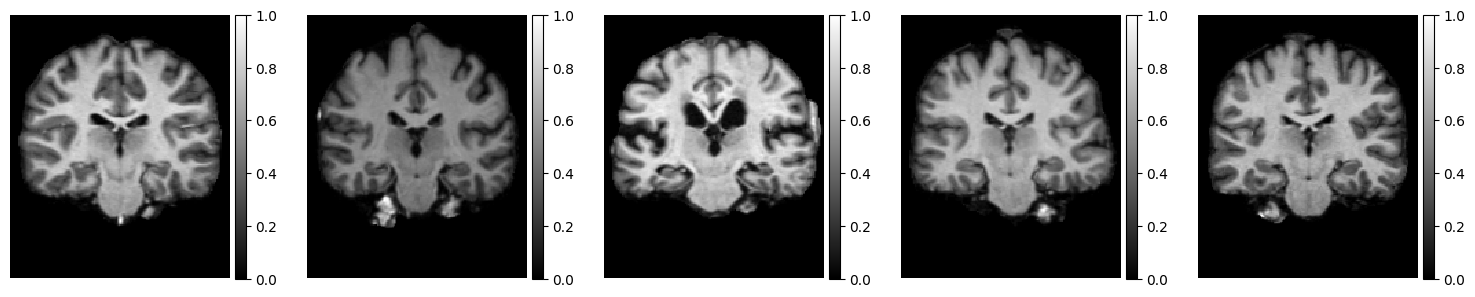

In [22]:
# Extract some random brain slices
nb_vis = 5
idx = np.random.choice(x_train.shape[0], nb_vis, replace=False)
example_brains = [x_train[i, ...] for i in idx]

# Visualize images, scaling each between 0 and 1
def normalize_image(img):
    min_val = img.min()
    max_val = img.max()
    if max_val > min_val:
        return (img - min_val) / (max_val - min_val)
    else:
        return img * 0

# Normalize to 0-1 range for consistent colorbar scaling
example_brains_normalized = []
for brain in example_brains:
    brain_norm = normalize_image(brain)
    example_brains_normalized.append(brain_norm)

# Visualize
ne.plot.slices(example_brains_normalized, cmaps=['gray'], do_colorbars=True);

# PyTorch Dataset and DataLoader

For PyTorch training, we'll create a custom Dataset class that provides pairs of images for registration.

In [23]:
from torch.utils.data import IterableDataset, DataLoader

class VxmIterableDataset(IterableDataset):
    """
    PyTorch IterableDataset for infinite VoxelMorph registration data.
    
    Yields random pairs of images for unsupervised registration training.
    """

    def __init__(self, x_data, device='cpu'):
        """
        Parameters
        ----------
        x_data : np.ndarray
            Array of images with shape (N, H, W).
        device : str
            Device to place tensors on.
        """
        self.x_data = x_data
        self.device = device
        self.vol_shape = x_data.shape[1:]
        self.ndims = len(self.vol_shape)

    def __iter__(self):
        """Generate infinite stream of random image pairs."""
        while True:
            # Sample random pair
            idx1 = np.random.randint(0, len(self.x_data))
            idx2 = np.random.randint(0, len(self.x_data))

            # Get images and add channel dimension
            moving = torch.from_numpy(self.x_data[idx1]).float().unsqueeze(0).to(self.device)  # (1, H, W)
            fixed = torch.from_numpy(self.x_data[idx2]).float().unsqueeze(0).to(self.device)   # (1, H, W)

            # Zero displacement for regularization loss
            zero_phi = torch.zeros(self.ndims, *self.vol_shape, device=self.device)  # (2, H, W)
            
            yield {
                'moving': moving,
                'fixed': fixed,
                'zero_phi': zero_phi
            }

# Create datasets
train_dataset = VxmIterableDataset(x_train[:2], device=device)
val_dataset = VxmIterableDataset(x_val[:2], device=device)

# Create dataloaders
batch_size = 8
train_loader = DataLoader(train_dataset, batch_size=batch_size, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=1, num_workers=0)

print(f'Created infinite IterableDataset with batch size {batch_size}')

Created infinite IterableDataset with batch size 8


Let's test the dataloader and visualize a batch:

Moving batch shape: torch.Size([8, 1, 192, 160])
Fixed batch shape: torch.Size([8, 1, 192, 160])
Zero phi shape: torch.Size([8, 2, 192, 160])


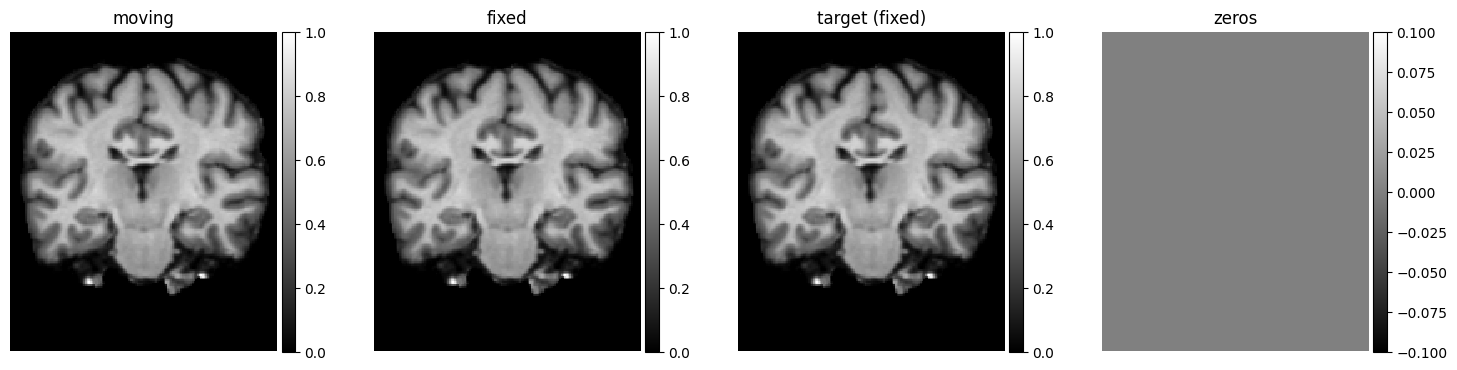

In [25]:
# Get a sample batch from the dataloader
sample_batch = next(iter(train_loader))

print('Moving batch shape:', sample_batch['moving'].shape)
print('Fixed batch shape:', sample_batch['fixed'].shape)
print('Zero phi shape:', sample_batch['zero_phi'].shape)

# Visualize first sample
images = [
    normalize_image(sample_batch['moving'][0, 0].cpu().numpy()),
    normalize_image(sample_batch['fixed'][0, 0].cpu().numpy()),
    normalize_image(sample_batch['fixed'][0, 0].cpu().numpy()),  # target is same as fixed
    sample_batch['zero_phi'][0, 0].cpu().numpy()
]
titles = ['moving', 'fixed', 'target (fixed)', 'zeros']
ne.plot.slices(images, titles=titles, cmaps=['gray'], do_colorbars=True);

# VoxelMorph Model

In [26]:
# Configure model parameters
ndim = 2
nb_features = [16, 16, 16, 16, 16]  # 5 levels for UNet architecture

# Build VxmPairwise model
vxm_model = vxm.nn.models.VxmPairwise(
    ndim=ndim,
    source_channels=1,
    target_channels=1,
    spatial_shape=vol_shape,
    nb_features=nb_features,
    integration_steps=0,
)

# Move model to device
vxm_model = vxm_model.to(device)

print('Model created successfully!')
print(f'Model is on device: {next(vxm_model.parameters()).device}')

Model created successfully!
Model is on device: cpu


### Loss Functions

For unsupervised registration, we use two loss terms:
1. **Image similarity loss**: MSE or NCC between moved and fixed images
2. **Regularization loss**: Spatial smoothness of the displacement field

In [27]:
# Define loss functions
# Image similarity: Mean Squared Error
image_loss_fn = vxm.nn.losses.MSE()

# Regularization: Spatial gradient (L2 penalty)
grad_loss_fn = vxm.nn.losses.Grad('l2')

# Loss weight for regularization (matching TensorFlow brain MRI demo)
lambda_param = 0.01
loss_weights = [1.0, lambda_param]

print(f'Image loss: MSE')
print(f'Regularization loss: Grad (l2) with weight {lambda_param}')

Image loss: MSE
Regularization loss: Grad (l2) with weight 0.01


### Optimizer

In [9]:
# Create optimizer (using lr=1e-4 as recommended for brain MRI)
optimizer = torch.optim.Adam(vxm_model.parameters(), lr=1e-4)

print('Optimizer: Adam with lr=1e-4')

Optimizer: Adam with lr=1e-4


# Train Model

Now we'll train the model using a manual PyTorch training loop.

In [10]:
def train_epoch(model, dataloader, optimizer, device, max_iter: int = 99):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    total_image_loss = 0
    total_grad_loss = 0

    for batch_idx, batch in enumerate(dataloader):
        # Get batch data
        moving = batch['moving']
        fixed = batch['fixed']
        zero_phi = batch['zero_phi']

        optimizer.zero_grad()

        # Forward pass - model returns (velocity/disp, warped_source)
        velocity, moved = model(moving, fixed, return_warped=True)

        # Compute losses
        img_loss = image_loss_fn.loss(fixed, moved)
        
        # Use the mean_loss method to get scalar output for PyTorch backward()
        grad_loss = grad_loss_fn.mean_loss(zero_phi, velocity)

        # Combined loss
        loss = loss_weights[0] * img_loss + loss_weights[1] * grad_loss

        loss.backward()
        optimizer.step()

        # Accumulate losses
        total_loss += loss.item()
        total_image_loss += img_loss.item()
        total_grad_loss += grad_loss.item()

        # Break after steps_per_epoch
        if batch_idx >= max_iter - 1:  # 100 steps per epoch
            break

    # num_batches = min(max_iter, len(dataloader))
    num_batches = 100
    return {
        'loss': total_loss / num_batches,
        'image_loss': total_image_loss / num_batches,
        'grad_loss': total_grad_loss / num_batches
    }

In [11]:
# Training configuration
nb_epochs = 100
steps_per_epoch = 100

# Training history
history = {'loss': [], 'image_loss': [], 'grad_loss': []}

print(f'Training for {nb_epochs} epochs...\n')

# Training loop
for epoch in range(nb_epochs):
    epoch_metrics = train_epoch(vxm_model, train_loader, optimizer, device, steps_per_epoch)

    # Store history
    for key in history:
        history[key].append(epoch_metrics[key])

    # Print progress
    print(f"Epoch {epoch+1}/{nb_epochs} - "
          f"loss: {epoch_metrics['loss']:.4f} - "
          f"image_loss: {epoch_metrics['image_loss']:.4f} - "
          f"grad_loss: {epoch_metrics['grad_loss']:.4f}")

print('\nTraining complete!')

Training for 100 epochs...

Epoch 1/100 - loss: 0.0215 - image_loss: 0.0215 - grad_loss: 0.0003
Epoch 2/100 - loss: 0.0209 - image_loss: 0.0209 - grad_loss: 0.0036
Epoch 3/100 - loss: 0.0183 - image_loss: 0.0180 - grad_loss: 0.0272
Epoch 4/100 - loss: 0.0158 - image_loss: 0.0150 - grad_loss: 0.0714
Epoch 5/100 - loss: 0.0148 - image_loss: 0.0140 - grad_loss: 0.0872
Epoch 6/100 - loss: 0.0137 - image_loss: 0.0128 - grad_loss: 0.0974
Epoch 7/100 - loss: 0.0130 - image_loss: 0.0118 - grad_loss: 0.1212
Epoch 8/100 - loss: 0.0123 - image_loss: 0.0110 - grad_loss: 0.1343
Epoch 9/100 - loss: 0.0119 - image_loss: 0.0106 - grad_loss: 0.1341
Epoch 10/100 - loss: 0.0116 - image_loss: 0.0103 - grad_loss: 0.1301
Epoch 11/100 - loss: 0.0114 - image_loss: 0.0102 - grad_loss: 0.1233
Epoch 12/100 - loss: 0.0110 - image_loss: 0.0098 - grad_loss: 0.1199
Epoch 13/100 - loss: 0.0109 - image_loss: 0.0097 - grad_loss: 0.1187
Epoch 14/100 - loss: 0.0107 - image_loss: 0.0096 - grad_loss: 0.1189
Epoch 15/100 - 

Let's visualize the training history:

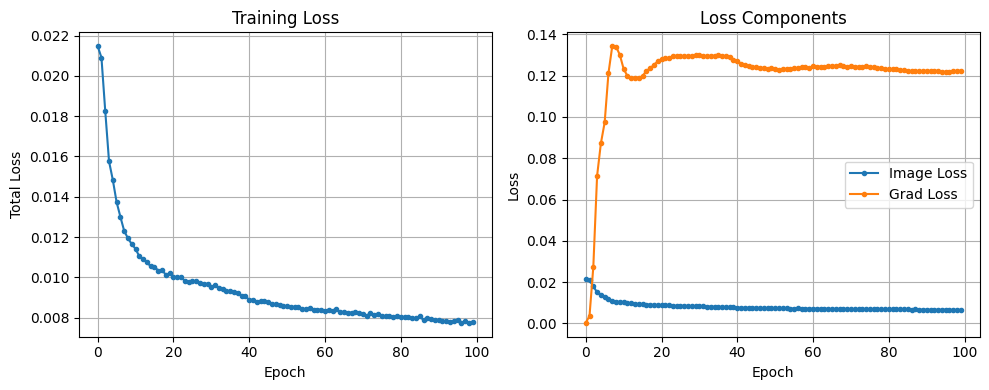

In [13]:
import matplotlib.pyplot as plt
def plot_history(history):
    """Plot training history."""
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history['loss'], '.-')
    plt.xlabel('Epoch')
    plt.ylabel('Total Loss')
    plt.title('Training Loss')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(history['image_loss'], '.-', label='Image Loss')
    plt.plot(history['grad_loss'], '.-', label='Grad Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss Components')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history)

Note: This is only 10 epochs for demonstration. For production, you would train for 100-200 epochs
until convergence.

# Registration

With learning-based registration, we simply evaluate the network for a new input pair.
Let's test on validation data:

In [14]:
# Get validation sample
vxm_model.eval()
val_sample = next(iter(val_loader))

val_moving = val_sample['moving']
val_fixed = val_sample['fixed']

print('Validation moving shape:', val_moving.shape)
print('Validation fixed shape:', val_fixed.shape)

Validation moving shape: torch.Size([1, 1, 192, 160])
Validation fixed shape: torch.Size([1, 1, 192, 160])


**Registration**: Predict the deformation field and warped image:

In [15]:
# Perform registration - model returns (velocity/disp, warped_source)
with torch.no_grad():
    val_velocity, val_moved = vxm_model(val_moving, val_fixed, return_warped=True)

print('Velocity field shape:', val_velocity.shape)
print('Moved image shape:', val_moved.shape)

Velocity field shape: torch.Size([1, 2, 192, 160])
Moved image shape: torch.Size([1, 1, 192, 160])


# Visualization

Let's visualize the registration results:

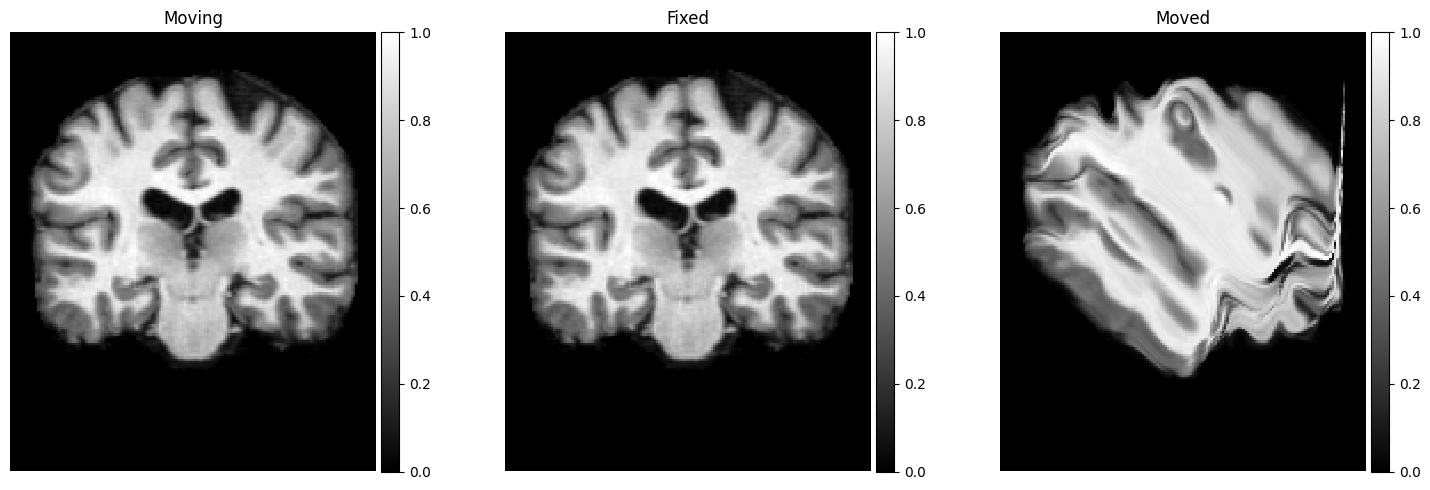

In [ ]:
# Move tensors to CPU for visualization
moving_img = val_moving[0, 0].cpu().numpy()
fixed_img = val_fixed[0, 0].cpu().numpy()
moved_img = val_moved[0, 0].cpu().numpy()
velocity_field = val_velocity[0].cpu().numpy()

images = [normalize_image(moving_img), normalize_image(fixed_img), normalize_image(moved_img)]

titles = ['Moving', 'Fixed', 'Moved']
ne.plot.slices(images, titles=titles, cmaps=['gray'], do_colorbars=True);

### Timing

Let's measure the registration speed:

In [17]:
# Warm-up
with torch.no_grad():
    _ = vxm_model(val_moving, val_fixed, return_warped=True)

# Time multiple runs
num_runs = 100
start_time = time.time()

with torch.no_grad():
    for _ in range(num_runs):
        _ = vxm_model(val_moving, val_fixed, return_warped=True)

elapsed = time.time() - start_time
ms_per_registration = (elapsed / num_runs) * 1000

print(f'Average registration time: {ms_per_registration:.2f} ms per image')
print(f'Registration speed: {1000/ms_per_registration:.1f} images/second')

Average registration time: 7.88 ms per image
Registration speed: 127.0 images/second


### Visualize Displacement Field

Let's visualize the displacement field as a flow:

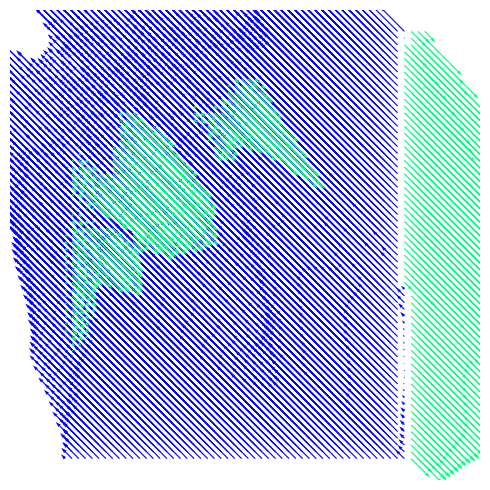

In [18]:
# Subsample the flow for better visualization
flow = velocity_field[:, ::3, ::3]  # (2, H//3, W//3)

# Transpose for neurite visualization: (H//3, W//3, 2)
flow_vis = flow.transpose(1, 2, 0)

# Plot flow
ne.plot.flow([flow_vis], width=5);